# Transformer Encoder and Decoder

## Start with the problem: turn one sequence into another

Imagine a system translating the source phrase “turn left” into another language. The source must first be represented in context. Then the output sequence must be produced in the correct order, with each new output conditioned on the source and the output prefix already available.

An **encoder–decoder Transformer** assigns these two jobs to two streams. The encoder produces a contextual vector for each source position. The decoder represents the target prefix, reads the encoded source through cross-attention, and supplies vectors to a next-token head.

The source and target can have different lengths. The encoder does not need to compress the source into one vector, and its outputs are not themselves the translated tokens. The decoder reads from that output sequence at each target position.

This lesson follows both streams, works a rectangular attention read, aligns training labels, and distinguishes teacher-forced training from generation. The [code companion](30_Transformer_Encoder_and_Decoder.ipynb) checks a tiny encoder–decoder forward pass with a causal target mask. Review [Transformers](27_Transformers_Notes.ipynb) and [Multi-Head Attention](29_Multi_Head_Attention_Notes.ipynb) for the sublayers.


## Keep the source path and target path visible

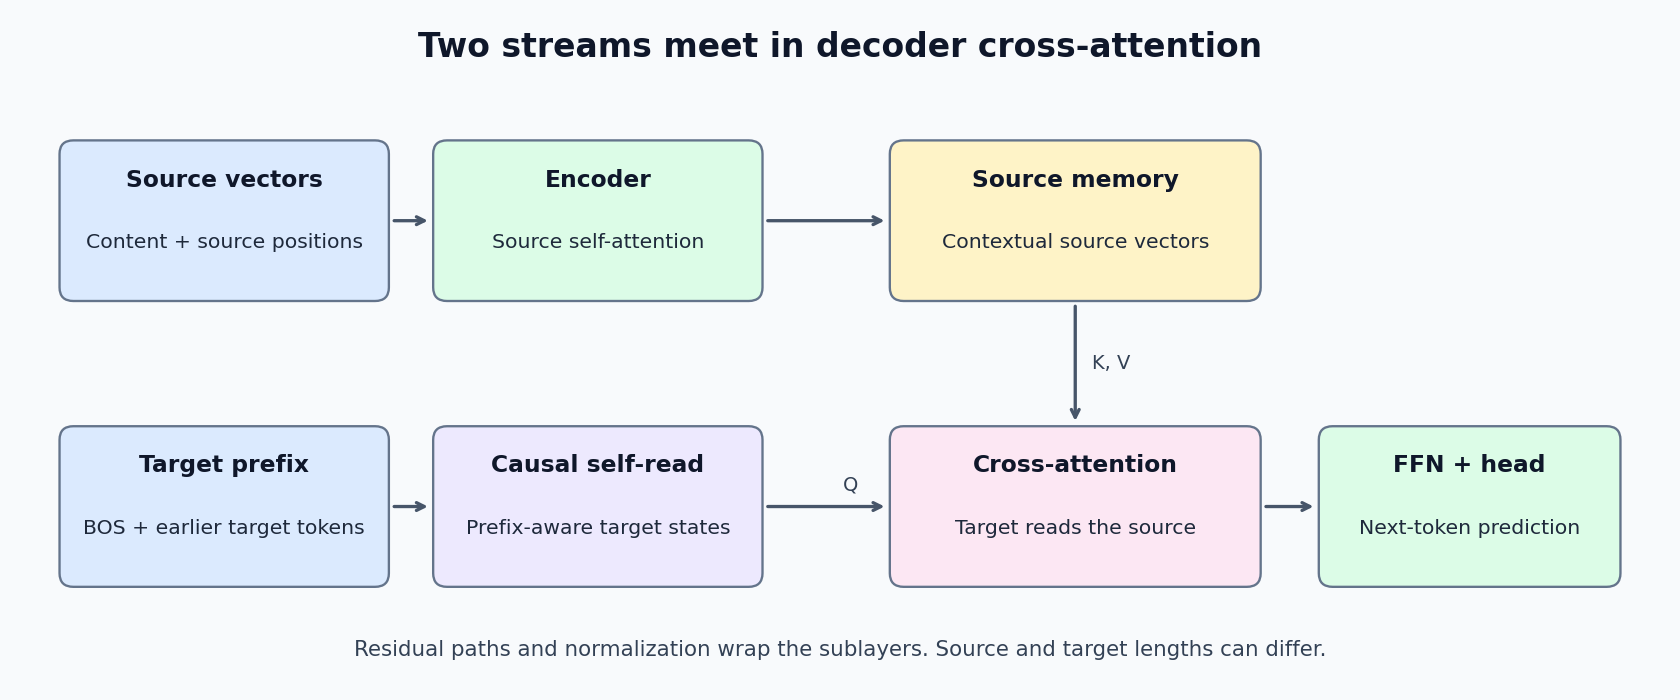

| Stream or stage | Receives | Produces |
| --- | --- | --- |
| Source representation | Source token IDs and source positions | Source vectors |
| Encoder | Source vectors and availability rules | Contextual source memory |
| Target representation | Shifted target IDs and target positions | Target-prefix vectors |
| Decoder self-attention | Target-prefix vectors | Prefix-aware target states |
| Decoder cross-attention | Target queries and source memory | Source-conditioned target states |
| Vocabulary head | Decoder vectors | Next-token logits |

The word **memory** here means the sequence of encoder output vectors supplied to the decoder. It does not imply an unlimited database or a separate persistent store beyond the example's encoded source.

The two streams need compatible dimensions at their attention interfaces. Their position indices are separate: source position two and target position two belong to different sequences.


## Let the encoder contextualize the whole available source

An encoder layer combines source self-attention with a positionwise feed-forward network, residual paths, and normalization. In a standard offline task, every valid source position can read every other valid source position.

For source tokens `[turn, left, EOS]`, the representation of “turn” can incorporate “left,” and the representation of “left” can incorporate “turn.” The resulting vectors describe these tokens in context rather than as isolated embedding lookups.

| Source query | turn | left | EOS |
| --- | --- | --- | --- |
| turn | Allow | Allow | Allow |
| left | Allow | Allow | Allow |
| EOS | Allow | Allow | Allow |

A padding mask removes artificial source positions. A streaming source task may require additional restrictions because the complete source is not yet available; unrestricted source attention would then change the task's information contract.

Each encoder layer updates all source vectors. Stacking layers repeats this communication and refinement. The final memory keeps one row per stored source position, while valid-length handling determines which rows can supply meaningful content.


## Let decoder self-attention represent the target prefix

The decoder begins with representations of the target tokens it has been supplied. For next-token learning, these are shifted inputs, such as `[BOS, go, left]`, rather than the labels `[go, left, EOS]` themselves at the same positions.

Masked self-attention allows each target position to read its own supplied token and earlier supplied tokens. Position one can read BOS and go; it cannot read the later input left, which would reveal its next-token label.

| Target query index | Input 0: BOS | Input 1: go | Input 2: left |
| --- | --- | --- | --- |
| 0 | Allow | Block | Block |
| 1 | Allow | Allow | Block |
| 2 | Allow | Allow | Allow |

This mask acts inside each decoder self-attention layer, not only at the output head. Otherwise a later layer could inherit future information already mixed into an earlier representation.

The prefix representation is then ready to form a query about the source. Its content depends on the target prefix, enabling different target positions to ask for different source information.


## Cross-attention is the link from target to source

In decoder cross-attention, queries come from target states, while keys and values come from encoder memory:

$$Q=HW^Q,\qquad K=MW^K,\qquad V=MW^V,$$
$$C=\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}+A\right)V.$$

Here $H$ is a matrix of target states, $M$ is source memory, and $A$ is an additive availability mask. The letter $M$ denotes memory here, not an attention mask; keeping that distinction visible avoids ambiguous equations.

| Quantity | Shape for two target positions and three source positions |
| --- | --- |
| Target queries | $2\times d_k$ |
| Source keys | $3\times d_k$ |
| Source values | $3\times d_v$ |
| Scores/weights | $2\times3$ |
| Cross-attention output | $2\times d_v$ |

Each target query gets its own distribution over source keys. Cross-attention usually permits the complete valid source in an offline transformation task. It does not use a triangular target-index/source-index rule merely because the decoder is autoregressive.


## Work one numerical cross-attention read

Choose target query $q=[1,0]$, source keys $[1,0]$, $[0,1]$, and $[1,1]$, and source values $[2,0]$, $[0,4]$, and $[2,4]$. With key width two, the scaled scores are $[1/\sqrt2,0,1/\sqrt2]$.

| Source position | Scaled score | Weight, approximately | Value |
| --- | --- | --- | --- |
| 0 | 0.707107 | 0.401112 | $[2,0]$ |
| 1 | 0.000000 | 0.197776 | $[0,4]$ |
| 2 | 0.707107 | 0.401112 | $[2,4]$ |

The output is approximately:

$$c=0.401112[2,0]+0.197776[0,4]+0.401112[2,4]$$
$$\approx[1.604448,2.395552].$$

The two equal scores produce equal weights. The second output coordinate receives contributions from the second and third values, even though the query's second coordinate was zero. Queries control matching; value coordinates control the content being returned.

If source position two is padding and blocked, the remaining weights become approximately $[0.669762,0.330238]$. The output changes to about $[1.339523,1.320954]$. A key-padding mask changes the normalization over available source content, not just the final sum's appearance.


## Follow the sublayer order without confusing normalization variants

A common decoder layer has three sublayers: causal target self-attention, source cross-attention, and a positionwise FFN. Residual connections wrap each update. The normalization arrangement must be specified.

The companion uses `nn.Transformer` with its default post-normalized arrangement. A schematic decoder layer is:

$$U=LN_1(H+\operatorname{SelfAttention}(H)),$$
$$V=LN_2(U+\operatorname{CrossAttention}(U,M)),$$
$$Y=LN_3(V+\operatorname{FFN}(V)).$$

The attention calls include their masks; cross-attention projects $U$ into queries and $M$ into keys and values. Dropout is omitted from the equations and set to zero in the companion.

The block in lesson 27 is pre-normalized, so its equations are deliberately different. Both variants use attention, residual paths, and refinement, but moving normalization changes the numerical computation.

The FFN does not directly read other source or target positions. It refines the features already gathered at each target position. Another decoder layer then repeats prefix communication and source reading with its own learned parameters.


## Align decoder inputs and labels one position apart

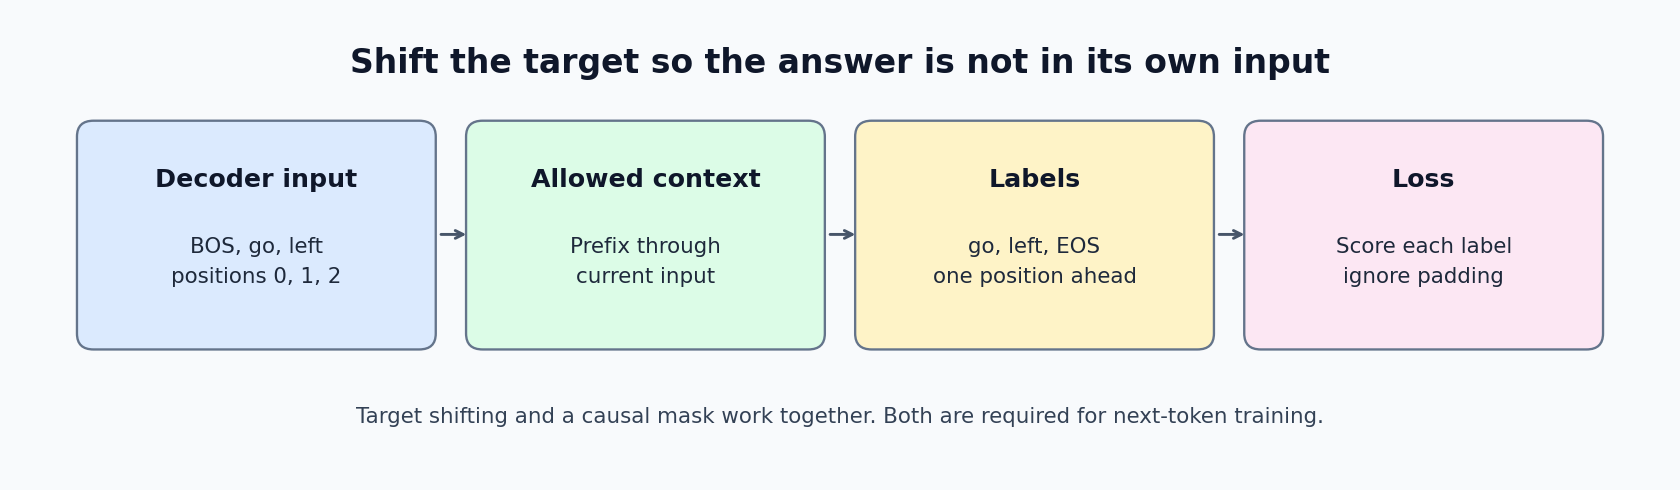

For target sequence `[go, left, EOS]`, construct:

| Position | Decoder input | Label | Prefix supplied to that prediction |
| --- | --- | --- | --- |
| 0 | BOS | go | BOS |
| 1 | go | left | BOS, go |
| 2 | left | EOS | BOS, go, left |

BOS means beginning of sequence, while EOS is a target symbol that tells generation when to stop. Their exact IDs come from the chosen vocabulary.

Using input `[go, left, EOS]` with the same labels would expose the answer at its own position. Removing the causal mask from shifted inputs would expose later target tokens. Shifting and masking jointly define the intended next-token task.

The decoder can calculate all these positions during teacher-forced training because the true target prefix is supplied. The causal mask ensures each position's prediction still depends only on the permitted part of that supplied sequence.


## Turn decoder vectors into a loss

A decoder produces width-$D$ vectors. A vocabulary head supplies logits $Z=YW_{head}+b$, with one score per vocabulary entry at every target position.

Suppose a three-class teaching head gives logits $[0,1,2]$ and class two is correct. Softmax probabilities are approximately $[0.090031,0.244728,0.665241]$, giving cross-entropy $-\ln(0.665241)\approx0.407606$.

The logit derivatives are $[0.090031,0.244728,-0.334759]$. Treating the logits as adjustable head biases for this isolated example, an SGD step with learning rate 0.1 gives approximately $[-0.009003,0.975527,2.033476]$. The correct-class logit rises relative to the others.

For three valid target positions with correct-token probabilities $[0.8,0.6,0.5]$, the mean cross-entropy is:

$$L=\frac{-\ln0.8-\ln0.6-\ln0.5}{3}\approx0.475705.$$

Full training propagates this objective through the head, decoder, cross-attention, encoder, and embeddings. Source vectors receive gradients through their contribution to decoder reads; they are not fixed merely because the source is observed before the target.


## Separate the three attention masks

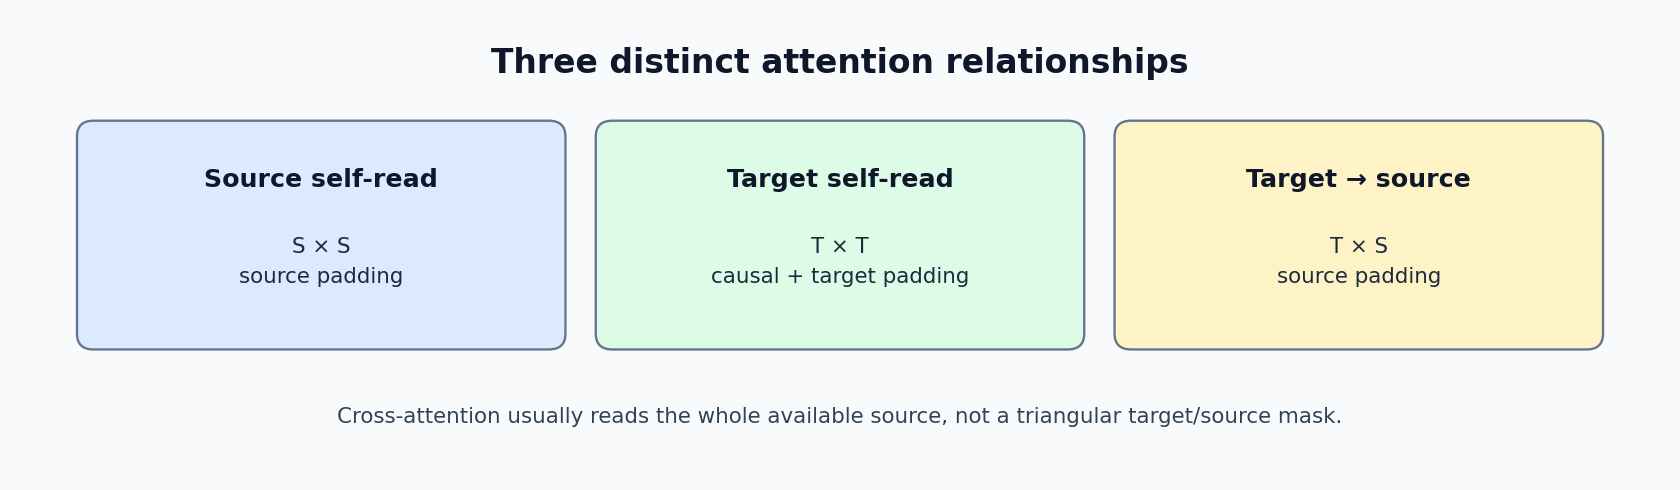

| Attention operation | Pair matrix | Typical restrictions |
| --- | --- | --- |
| Encoder source self-attention | $S\times S$ | Source padding |
| Decoder target self-attention | $T\times T$ | Target causal rule and target padding |
| Decoder cross-attention | $T\times S$ | Source padding, plus any task-specific source availability |

In PyTorch `nn.Transformer`, Boolean mask entries set to `True` block attention. `src_key_padding_mask` marks encoder source padding; `tgt_key_padding_mask` marks target padding; `memory_key_padding_mask` prevents decoder cross-attention from reading padded encoder positions. A target causal mask is supplied separately. See the [official Transformer interface](https://docs.pytorch.org/docs/stable/generated/torch.nn.Transformer.html).

These masks are not interchangeable merely because two sequences happen to have equal lengths. A loss mask also excludes padded labels, but it does not enforce attention availability by itself.

An entirely blocked real query needs deliberate handling. More commonly, valid target positions can always read BOS or another permitted target input and at least one valid source position, avoiding an empty distribution.


## Trace the companion's exact tensor interface

The companion sets model width eight, two heads, one encoder layer, one decoder layer, FFN width sixteen, zero dropout, and batch-first layout. It supplies random continuous vectors rather than token IDs.

| Object | Companion shape | Meaning |
| --- | --- | --- |
| Source | $(1,3,8)$ | One example, three source positions |
| Target prefix | $(1,2,8)$ | One example, two target positions |
| Target causal mask | $(2,2)$ | Blocks target position zero from reading one |
| Encoder memory | $(1,3,8)$ | Contextual source representations |
| Decoder output | $(1,2,8)$ | One representation per target query |

The Boolean target mask is $[[False,True],[False,False]]$. The printed integer matrix has a one above the diagonal, marking the blocked future relationship.

This low-level Transformer module expects representations. The companion does not add token embeddings, position vectors, a vocabulary head, or shifted token labels. Those components are required for a complete token-based training system, but the saved example establishes the continuous-vector shape and mask interface only. It makes no translation-quality claim.


## Generate from a source one target token at a time

At inference, the source can be encoded once. Start the target prefix with BOS, compute the decoder's final-position logits, choose or sample a token, append it to the prefix, and repeat until EOS or another defined stopping condition.

| Generation step | Decoder prefix | Next prediction |
| --- | --- | --- |
| 1 | BOS | First target token |
| 2 | BOS, generated token 1 | Second target token |
| 3 | BOS, generated tokens 1 and 2 | Third target token |

Teacher-forced training supplies true earlier tokens; free-running generation consumes the model's own choices. An early error can therefore change all later prefixes. Good teacher-forced loss alone does not establish good complete-sequence outputs.

Greedy selection chooses the highest score. Sampling draws from a defined distribution. Beam search retains several candidate prefixes according to a scoring rule. Each procedure changes the generated behavior and should be evaluated for the task rather than treated as part of the encoder's job.

Caching unchanged target keys/values and source projections can reduce repeated work, while position offsets and masks must still remain correct.


## Handle variable source and target lengths

Source and target batches can need different padding. A source of length three and a target of length five do not share a single validity mask. Track valid lengths independently.

| Item | What must be excluded |
| --- | --- |
| Source padding in encoder | Artificial source keys |
| Source padding in cross-attention | Artificial memory keys/values |
| Target padding in self-attention | Artificial prefix keys |
| Target padding in loss | Artificial labels |

A decoder may still compute vectors for padded target queries. Ignoring their labels prevents those outputs from contributing to the objective, while attention masks protect the real positions' reads.

For a valid-token mean loss, divide by the number of non-padding labels rather than the rectangular batch's stored position count. A sequence-balanced mean is a different weighting choice. The [Sequence Modeling lesson](25_Sequence_Modeling_Notes.ipynb) demonstrates these denominators numerically.

Training examples with no valid source or target need an explicit policy rather than an accidental all-masked softmax or a division by zero. Define the data contract before batching.


## Compare architectures and understand the pair counts

| Arrangement | Main reads | Natural interface |
| --- | --- | --- |
| Encoder-only | Source self-attention | Represent or label an available input |
| Decoder-only | Causal attention over one token stream | Continue a prefix |
| Encoder–decoder | Source self-attention, target self-attention, cross-attention | Produce an output conditioned on a source |

An explicit two-stream design makes source and target availability easy to distinguish. Other architectures can also perform source-conditioned tasks, so the interface alone does not establish superior quality.

With source length $S$ and target length $T$, dense pair counts per corresponding attention operation are $S^2$, $T^2$, and $TS$. For $S=3$ and $T=2$, these are nine, four, and six, before accounting for heads, layers, and causal exclusions.

Doubling both lengths quadruples these pair counts. Cross-attention becomes costly when both source and target are long. Projection and FFN work add further cost, and actual memory use depends on the attention implementation.


## Inspect common failures before trusting a training score

| Symptom | First investigation |
| --- | --- |
| Extremely low next-token loss immediately | Unshifted labels or future-target leakage |
| Target output length follows the source | Query/source axis confusion |
| Extra source padding changes valid predictions | Encoder and memory padding masks |
| Manual block differs from library output | Normalization order, projections, biases, and dropout |
| Training loss looks good, generated sequences fail | Free-running evaluation and stopping rules |
| Source-conditioned predictions ignore the source | Compare against a source-ablated baseline |

Useful behavioral checks include editing a forbidden future target token and confirming that earlier causal predictions stay unchanged, or adding masked source padding and checking valid outputs. Keep dropout disabled for deterministic comparisons.

A complete evaluation holds out independent source–target pairs and uses a task-appropriate sequence metric or error analysis. Shape assertions establish interface behavior; fitting establishes performance on the fitted examples; held-out generation addresses the actual source-to-target task.


## Practice the two streams and retain the contract

1. For four target queries and seven source keys, what shape is each head's cross-attention score matrix?
2. Which stream supplies cross-attention queries?
3. For target `[a, b, EOS]`, what is the shifted decoder input?
4. Does a target causal mask block the decoder from reading the complete available source?
5. Does the companion's $(1,2,8)$ output already contain vocabulary probabilities?

**Answers.** Each head has a $4\times7$ matrix. The target decoder stream supplies queries, while encoder memory supplies keys and values. The shifted input is `[BOS, a, b]`. Target causality restricts target self-attention; source availability is a separate cross-attention rule. The companion output contains representations, which require a vocabulary head to become logits.

**Remember:** encode the available source, represent the permitted target prefix, read the source through cross-attention, and predict the next target token. Shifted labels, distinct masks, and a specified generation procedure turn the architecture into a well-defined learning task.

Continue with [BERT and Encoder Models](31_BERT_and_Encoder_Models_Notes.ipynb) and [GPT and Autoregressive Models](32_GPT_and_Autoregressive_Models_Notes.ipynb) to explore encoder-only and decoder-only objectives.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
